In [32]:
import numpy as np
import matplotlib.pyplot as plt
import math

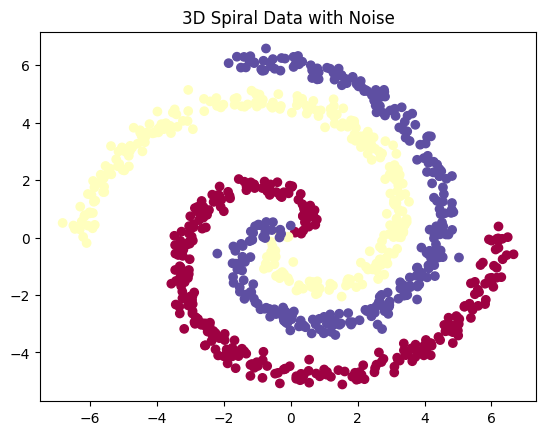

In [33]:
import numpy as np
import matplotlib.pyplot as plt


def generate_spiral_data(points, noise=0.5):
    n = points // 3  # Divide points equally among three spirals
    theta = np.sqrt(np.random.rand(n)) * 2 * np.pi  # Angle for spiral

    # Generate first spiral
    x1 = np.cos(theta) * theta
    y1 = np.sin(theta) * theta
    x1 += np.random.normal(scale=noise, size=n)
    y1 += np.random.normal(scale=noise, size=n)

    # Generate second spiral
    x2 = -np.cos(theta) * theta
    y2 = -np.sin(theta) * theta
    x2 += np.random.normal(scale=noise, size=n)
    y2 += np.random.normal(scale=noise, size=n)

    # Generate third spiral
    # Offset the angle for the third spiral
    x3 = np.cos(theta + np.pi/1.7) * theta
    y3 = np.sin(theta + np.pi/1.7) * theta
    x3 += np.random.normal(scale=noise, size=n)
    y3 += np.random.normal(scale=noise, size=n)

    # Combine the points and create labels
    X = np.vstack((np.vstack((x1, y1)).T,
                   np.vstack((x2, y2)).T,
                   np.vstack((x3, y3)).T))
    Y = np.hstack((np.zeros(n), np.ones(n), np.full(n, 2)))

    return X, Y


# Generate the data
points = 900  # Ensure the total number of points is divisible by 3
noise = 0.2
X, Y = generate_spiral_data(points, noise)

# Plot the data
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Spectral)
plt.title("3D Spiral Data with Noise")
plt.show()

In [34]:
Y = Y.astype(int)
# print(Y)

In [35]:
class NN:
    def __init__(self, n_features, n_hidden, n_classes):
        self.d = n_features
        self.h = n_hidden
        self.n = n_classes

        self.W1 = 0.01*np.random.randn(self.d, self.h)
        self.b1 = np.zeros((1, self.h))
        self.W2 = 0.01*np.random.randn(self.h, self.n)
        self.b2 = np.zeros((1,self.n))

    def fwd_prop(self, X):
        Z1 = np.dot(X, self.W1) + self.b1

        A1 = np.maximum(0, Z1)      #* relu
        Z2 = np.dot(A1, self.W2) + self.b2


        Z2 = np.exp(Z2)         #* softmax
        A2 = Z2/np.sum(Z2, axis=1, keepdims=True)

        return A1, A2
    
    def calc_loss(self, y, probs):
        n_examples = y.shape[0]
        corr_log_probs = - np.log(probs[range(n_examples), y])
        loss = np.sum(corr_log_probs)/n_examples

        return loss
    
    def back_prop(self, X, A1, A2, y):
        n_examples = y.shape[0]
        dZ2 = A2
        dZ2[range(n_examples), y]-=1
        dZ2 /=n_examples

        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis =0, keepdims=True)

        dA1 =np.dot(dZ2, self.W2.T)
        dA1[A1<=0] = 0

        dZ1 = dA1
        dW1 = np.dot(X.T, dZ1)
        db1 =np.sum(dZ1, axis = 0, keepdims=True)
        return dW1, db1, dW2, db2
    



    def fit(self, X, lr, reg, max_iters):
        n_examples = X.shape[0]

        for i in range(max_iters):
            A1, A2 = self.fwd_prop(X)

            data_loss = self.calc_loss(Y, A2)
            reg_loss = 0.5 * reg * \
                np.sum(self.W1*self.W1) + 0.5 * reg * np.sum(self.W2 *self.W2)
            
            loss = data_loss + reg_loss

            if i%250 ==0:
                print("Iteration %d: loss %f" %(i, loss))
            
            dW1, db1, dW2, db2 = self.back_prop(X,A1, A2, Y)

            dW1 += reg * self.W1
            dW2 += reg * self.W2

            self.W1 -= lr * dW1
            self.b1 -= lr * db1
            self.W2 -= lr * dW2
            self.b2 -= lr * db2

    def predict(self, X):
        A1 = np.maximum(0, np.dot(X, self.W1) + self.b1)
        Z2 = np.dot(A1, self.W2) + self.b2
        y_hat = np.argmax(Z2, axis=1)

        return y_hat
    


In [36]:
nn_model = NN(n_features=2, n_hidden=100, n_classes=3)
nn_model.fit(X, lr=1, reg=1e-3, max_iters=10000)

Iteration 0: loss 1.098197
Iteration 250: loss 0.389364
Iteration 500: loss 0.297728
Iteration 750: loss 0.243929
Iteration 1000: loss 0.210272
Iteration 1250: loss 0.192446
Iteration 1500: loss 0.162998
Iteration 1750: loss 0.173604
Iteration 2000: loss 0.131041
Iteration 2250: loss 0.115181
Iteration 2500: loss 0.212899
Iteration 2750: loss 0.374859
Iteration 3000: loss 0.143845
Iteration 3250: loss 0.183849
Iteration 3500: loss 0.183881
Iteration 3750: loss 0.190320
Iteration 4000: loss 0.160125
Iteration 4250: loss 0.175200
Iteration 4500: loss 0.233133
Iteration 4750: loss 0.144564
Iteration 5000: loss 0.143159
Iteration 5250: loss 0.181798
Iteration 5500: loss 0.148900
Iteration 5750: loss 0.249575
Iteration 6000: loss 0.122724
Iteration 6250: loss 0.115759
Iteration 6500: loss 0.113624
Iteration 6750: loss 0.111876
Iteration 7000: loss 0.109820
Iteration 7250: loss 0.108885
Iteration 7500: loss 0.133955
Iteration 7750: loss 0.131919
Iteration 8000: loss 0.149052
Iteration 8250: 

In [37]:
Z = nn_model.predict(X)
unique_values, counts = np.unique(Z, return_counts=True)

print("Unique values:", unique_values)
print("Counts:", counts)

Unique values: [0 1 2]
Counts: [299 301 300]


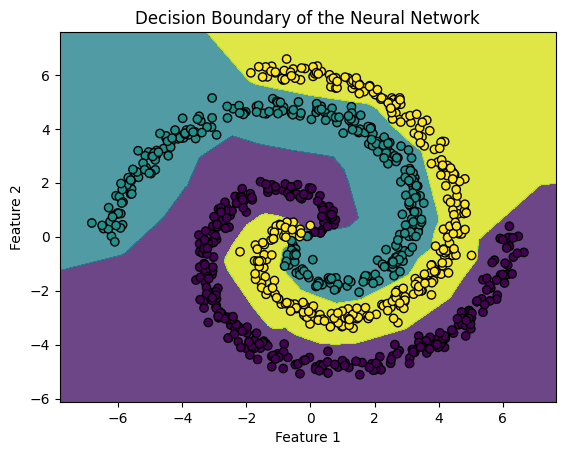

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Create a meshgrid
h = 0.01  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict the class for each point in the meshgrid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = nn_model.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.8)

# Plot the original data points
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors='k', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary of the Neural Network')
plt.show()